# 4. The Quest - S&P 500 Stocks Prediction
---
Q2 (ML/DL regression): predpovedajte nastávajúcu situáciu podľa historických dát 4.1

## 4.1 EDA and data preprocessing 	(5b) 
- (A-4b) EDA a data preprocessing pre Vami vybrané charakteristiky z datasetu 
- (B-1b) Zdôvodnite výber ML/DL metód vzhľadom na Vami vybraný dataset pre 4.2
## 4.2 Modeling and evaluation (5b)
- (A-4b) Modeluje Vami tie vybrané charakteristiky pomocou vhodných ML/DL metód. 	Výsledok modelovania je najlepší model.
- (B-1b) Zhodnotíte Váš prístup a získaný výsledok				



# 4.1 EDA and data preprocessing

In [65]:
import kagglehub
import pandas as pd
import os

## Načítanie dát

In [2]:
# Download latest version
path = kagglehub.dataset_download("andrewmvd/sp-500-stocks")

print("Path to dataset files:", path)
os.listdir(path)

Path to dataset files: /Users/johanna/.cache/kagglehub/datasets/andrewmvd/sp-500-stocks/versions/1023


['sp500_stocks.csv', 'sp500_companies.csv', 'sp500_index.csv']

In [3]:
df_stocks = pd.read_csv(f"{path}/sp500_stocks.csv")
df_companies = pd.read_csv(f"{path}/sp500_companies.csv")
df_index = pd.read_csv(f"{path}/sp500_index.csv")

### Dataset Stocks

In [4]:
df_stocks.shape

(1891536, 8)

In [5]:
df_stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1891536 entries, 0 to 1891535
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Date       object 
 1   Symbol     object 
 2   Adj Close  float64
 3   Close      float64
 4   High       float64
 5   Low        float64
 6   Open       float64
 7   Volume     float64
dtypes: float64(6), object(2)
memory usage: 115.5+ MB


In [6]:
df_stocks.head()

,Date,Symbol,Adj Close,Close,High,Low,Open,Volume
0,2010-01-04,MMM,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,MMM,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,MMM,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,MMM,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,MMM,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_stocks.isnull().sum()

Date               0
Symbol             0
Adj Close    1273705
Close        1273705
High         1273705
Low          1273705
Open         1273705
Volume       1273705
dtype: int64

In [8]:
df_stocks.nunique()

Date           3768
Symbol          502
Adj Close    525360
Close        123637
High         123036
Low          122480
Open         121187
Volume       208513
dtype: int64

In [9]:
df_stocks.describe()

,Adj Close,Close,High,Low,Open,Volume
count,617831.000000,617831.000000,617831.000000,617831.000000,617831.000000,6.178310e+05
mean,79.672357,87.471540,88.417844,86.480997,87.460302,9.347125e+06
std,102.742931,104.521901,105.684113,103.300770,104.519845,4.771669e+07
min,0.203593,0.222000,0.226250,0.216250,0.218000,0.000000e+00
25%,26.572459,32.700001,33.060001,32.299999,32.689999,1.144000e+06
50%,49.821613,59.139999,59.720001,58.500000,59.119999,2.453400e+06
75%,94.831036,105.019997,106.129997,103.889999,105.000000,5.657850e+06
max,1702.530029,1702.530029,1714.750000,1696.900024,1706.400024,3.692928e+09


### Dataset Companies

In [10]:
df_companies.shape

(502, 16)

In [11]:
df_companies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Exchange             502 non-null    object 
 1   Symbol               502 non-null    object 
 2   Shortname            502 non-null    object 
 3   Longname             502 non-null    object 
 4   Sector               502 non-null    object 
 5   Industry             502 non-null    object 
 6   Currentprice         502 non-null    float64
 7   Marketcap            502 non-null    int64  
 8   Ebitda               473 non-null    float64
 9   Revenuegrowth        499 non-null    float64
 10  City                 502 non-null    object 
 11  State                482 non-null    object 
 12  Country              502 non-null    object 
 13  Fulltimeemployees    493 non-null    float64
 14  Longbusinesssummary  502 non-null    object 
 15  Weight               502 non-null    flo

In [12]:
df_companies.head()

,Exchange,Symbol,Shortname,Longname,Sector,Industry,Currentprice,Marketcap,Ebitda,Revenuegrowth,City,State,Country,Fulltimeemployees,Longbusinesssummary,Weight
0,NMS,AAPL,Apple Inc.,Apple Inc.,Technology,Consumer Electronics,254.49,3846819807232,1.346610e+11,0.061,Cupertino,CA,United States,164000.0,"Apple Inc. designs, manufactures, and markets ...",0.069209
1,NMS,NVDA,NVIDIA Corporation,NVIDIA Corporation,Technology,Semiconductors,134.70,3298803056640,6.118400e+10,1.224,Santa Clara,CA,United States,29600.0,NVIDIA Corporation provides graphics and compu...,0.059350
2,NMS,MSFT,Microsoft Corporation,Microsoft Corporation,Technology,Software - Infrastructure,436.60,3246068596736,1.365520e+11,0.160,Redmond,WA,United States,228000.0,Microsoft Corporation develops and supports so...,0.058401
3,NMS,AMZN,"Amazon.com, Inc.","Amazon.com, Inc.",Consumer Cyclical,Internet Retail,224.92,2365033807872,1.115830e+11,0.110,Seattle,WA,United States,1551000.0,"Amazon.com, Inc. engages in the retail sale of...",0.042550
4,NMS,GOOGL,Alphabet Inc.,Alphabet Inc.,Communication Services,Internet Content & Information,191.41,2351625142272,1.234700e+11,0.151,Mountain View,CA,United States,181269.0,Alphabet Inc. offers various products and plat...,0.042309


In [13]:
df_companies.isnull().sum()

Exchange                0
Symbol                  0
Shortname               0
Longname                0
Sector                  0
Industry                0
Currentprice            0
Marketcap               0
Ebitda                 29
Revenuegrowth           3
City                    0
State                  20
Country                 0
Fulltimeemployees       9
Longbusinesssummary     0
Weight                  0
dtype: int64

In [14]:
df_companies.nunique()

Exchange                 4
Symbol                 502
Shortname              499
Longname               499
Sector                  11
Industry               114
Currentprice           499
Marketcap              502
Ebitda                 469
Revenuegrowth          260
City                   235
State                   41
Country                  8
Fulltimeemployees      387
Longbusinesssummary    499
Weight                 502
dtype: int64

In [15]:
df_companies.describe()

,Currentprice,Marketcap,Ebitda,Revenuegrowth,Fulltimeemployees,Weight
count,502.000000,5.020000e+02,4.730000e+02,499.000000,4.930000e+02,502.000000
mean,217.893685,1.107222e+11,7.045286e+09,0.070541,5.782761e+04,0.001992
std,489.205027,3.440074e+11,1.624213e+10,0.180247,1.395988e+05,0.006189
min,9.400000,4.664099e+09,-3.991000e+09,-0.602000,2.800000e+01,0.000084
25%,68.547500,1.933417e+10,1.625000e+09,0.002000,1.020000e+04,0.000348
50%,118.365000,3.706396e+10,2.952748e+09,0.051000,2.169000e+04,0.000667
75%,227.667500,7.830565e+10,6.020000e+09,0.109000,5.510000e+04,0.001409
max,8276.780000,3.846820e+12,1.495470e+11,1.632000,2.100000e+06,0.069209


### Dataset Index

In [16]:
df_index.shape

(2517, 2)

In [17]:
df_index.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2517 entries, 0 to 2516
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2517 non-null   object 
 1   S&P500  2517 non-null   float64
dtypes: float64(1), object(1)
memory usage: 39.5+ KB


In [18]:
df_index.head()

,Date,S&P500
0,2014-12-22,2078.54
1,2014-12-23,2082.17
2,2014-12-24,2081.88
3,2014-12-26,2088.77
4,2014-12-29,2090.57


In [19]:
df_index.isnull().sum()

Date      0
S&P500    0
dtype: int64

In [20]:
df_index.nunique()

Date      2517
S&P500    2505
dtype: int64

In [21]:
df_index.describe()

,S&P500
count,2517.000000
mean,3346.351605
std,1078.204274
min,1829.080000
25%,2428.370000
50%,2999.910000
75%,4199.120000
max,6090.270000


## 4.1a EDA a data preprocessing pre vybrané charakteristiky z datasetu

### EDA

#### Analyza null hodnot

In [22]:
# df_stocks
print("\ndf_stocks:")
print(f"   Shape: {df_stocks.shape}")
null_stocks = df_stocks.isnull().sum()
null_pct = (null_stocks / len(df_stocks) * 100).round(2)
print(pd.DataFrame({'Null Count': null_stocks, 'Null %': null_pct}))

# df_companies
print("\ndf_companies:")
print(f"   Shape: {df_companies.shape}")
null_companies = df_companies.isnull().sum()
null_pct_comp = (null_companies / len(df_companies) * 100).round(2)
print(pd.DataFrame({'Null Count': null_companies, 'Null %': null_pct_comp})[null_companies > 0])

# df_index
print("\ndf_index:")
print(f"   Shape: {df_index.shape}")
print(df_index.isnull().sum())


df_stocks:
   Shape: (1891536, 8)
           Null Count  Null %
Date                0    0.00
Symbol              0    0.00
Adj Close     1273705   67.34
Close         1273705   67.34
High          1273705   67.34
Low           1273705   67.34
Open          1273705   67.34
Volume        1273705   67.34

df_companies:
   Shape: (502, 16)
                   Null Count  Null %
Ebitda                     29    5.78
Revenuegrowth               3    0.60
State                      20    3.98
Fulltimeemployees           9    1.79

df_index:
   Shape: (2517, 2)
Date      0
S&P500    0
dtype: int64


#### Kontrola duplikátov

In [23]:
dup_stocks = df_stocks.duplicated(subset=['Date', 'Symbol']).sum()
print(f"df_stocks duplicity: {dup_stocks}")

dup_companies = df_companies.duplicated(subset=['Symbol']).sum()
print(f"df_companies duplicity: {dup_companies}")

dup_index = df_index.duplicated(subset=['Date']).sum()
print(f"df_index duplicity: {dup_index}")

df_stocks duplicity: 0
df_companies duplicity: 0
df_index duplicity: 0


#### Konverzia dátumov

In [38]:
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
df_index['Date'] = pd.to_datetime(df_index['Date'])

#### Kontrola dátových typov

In [39]:
# Kontrola dátových typov
print("\ndf_stocks:")
print(df_stocks.dtypes)

print("\ndf_companies:")
print(df_companies.dtypes)

print("\ndf_index:")
print(df_index.dtypes)


df_stocks:
Date         datetime64[ns]
Symbol               object
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume              float64
dtype: object

df_companies:
Exchange                object
Symbol                  object
Shortname               object
Longname                object
Sector                  object
Industry                object
Currentprice           float64
Marketcap                int64
Ebitda                 float64
Revenuegrowth          float64
City                    object
State                   object
Country                 object
Fulltimeemployees      float64
Longbusinesssummary     object
Weight                 float64
dtype: object

df_index:
Date      datetime64[ns]
S&P500           float64
dtype: object


#### Casovy rozsah datasetov

In [40]:
print("Časový rozsah dát:")
print(f"  df_stocks: od {df_stocks['Date'].min()} do {df_stocks['Date'].max()}")
print(f"  df_index:  od {df_index['Date'].min()} do {df_index['Date'].max()}")
print(f"\nPočet unikátnych akcií: {df_stocks['Symbol'].nunique()}")

Časový rozsah dát:
  df_stocks: od 2010-01-04 00:00:00 do 2024-12-20 00:00:00
  df_index:  od 2014-12-22 00:00:00 do 2024-12-20 00:00:00

Počet unikátnych akcií: 502


Dataset ``df_stocks`` obsahuje dáta od 04.01.2010 do 20.12.2024, zatiaľ čo dataset ``df_index`` obsahuje dáta od 22.12.2014 do 20.12.2024
. Pre účely modelovania budeme pracovať s dátami od **22.12.2014**, aby sme mali konzistentný časový rozsah.

#### Chýbajúce hodnoty v datasete ``stocks``

In [26]:
print('Percentage of missing values in each column:')
print(df_stocks.isnull().sum()/len(df_stocks)*100)

Percentage of missing values in each column:
Date          0.000000
Symbol        0.000000
Adj Close    67.337074
Close        67.337074
High         67.337074
Low          67.337074
Open         67.337074
Volume       67.337074
dtype: float64


V datasete ``df_stocks``sa nachadaz najviac chybajúcich hodnot, okrem stlpcov ``Date``a ``Symbol``, v kazdom chyba 67.67% hodnot. Tieto stlpce vsak nebudeme pouzivat pre modelovanie, pretoze sa jedna o identifikatory a casove oznacenia.

In [42]:
stock_completeness = df_stocks.groupby('Symbol').agg(
    Total_Rows=('Close', 'count'),
    Valid_Rows=('Close', lambda x: x.notna().sum()),
    Date_Min=('Date', 'min'),
    Date_Max=('Date', 'max')
).reset_index()

stock_completeness.head()

,Symbol,Total_Rows,Valid_Rows,Date_Min,Date_Max
0,A,0,0,2010-01-04,2024-12-20
1,AAPL,0,0,2010-01-04,2024-12-20
2,ABBV,3014,3014,2010-01-04,2024-12-20
3,ABNB,0,0,2010-01-04,2024-12-20
4,ABT,3768,3768,2010-01-04,2024-12-20


In [43]:
stock_completeness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Symbol      502 non-null    object        
 1   Total_Rows  502 non-null    int64         
 2   Valid_Rows  502 non-null    int64         
 3   Date_Min    502 non-null    datetime64[ns]
 4   Date_Max    502 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(1)
memory usage: 19.7+ KB


In [44]:
# zplostenie stlpcov
stock_completeness['Completeness_Percentage'] = (stock_completeness['Valid_Rows'] / stock_completeness['Total_Rows']) * 100

stock_completeness = stock_completeness.sort_values(by ='Valid_Rows', ascending=False)

stock_completeness.head(15)

,Symbol,Total_Rows,Valid_Rows,Date_Min,Date_Max,Completeness_Percentage
257,JCI,3768,3768,2010-01-04,2024-12-20,100.0
129,DE,3768,3768,2010-01-04,2024-12-20,100.0
133,DG,3768,3768,2010-01-04,2024-12-20,100.0
135,DHI,3768,3768,2010-01-04,2024-12-20,100.0
137,DIS,3768,3768,2010-01-04,2024-12-20,100.0
138,DLR,3768,3768,2010-01-04,2024-12-20,100.0
408,SHW,3768,3768,2010-01-04,2024-12-20,100.0
241,INCY,3768,3768,2010-01-04,2024-12-20,100.0
141,DOV,3768,3768,2010-01-04,2024-12-20,100.0
406,SBUX,3768,3768,2010-01-04,2024-12-20,100.0


### Základné štatistiky

#### Výber akcií s kompletnými dátami

In [46]:
# Výber akcií s 100% kompletnosťou (3768 dní)
complete_stocks = stock_completeness[stock_completeness['Valid_Rows'] == 3768]['Symbol'].tolist()
print(f"Počet akcií s kompletnými dátami: {len(complete_stocks)}")

# Filtrovanie df_stocks na kompletné akcie
df_clean = df_stocks[df_stocks['Symbol'].isin(complete_stocks)].copy()
df_clean = df_clean.dropna(subset=['Close'])

print(f"Shape čistého datasetu: {df_clean.shape}")

Počet akcií s kompletnými dátami: 150
Shape čistého datasetu: (565200, 8)


In [31]:
df_clean[['Open', 'Close', 'High', 'Low', 'Volume']].describe()

,Open,Close,High,Low,Volume
count,565200.000000,565200.000000,565200.000000,565200.000000,5.652000e+05
mean,87.920313,87.931672,88.865829,86.952098,9.073506e+06
std,106.585525,106.588070,107.761249,105.352975,4.887218e+07
min,0.218000,0.222000,0.226250,0.216250,0.000000e+00
25%,33.209827,33.219435,33.580002,32.834876,1.157900e+06
50%,59.353888,59.379923,59.950001,58.740002,2.439400e+06
75%,104.370003,104.400002,105.480215,103.269997,5.505625e+06
max,1706.400024,1702.530029,1714.750000,1696.900024,3.692928e+09


In [47]:
stats_comparison = pd.DataFrame({
    'Mean': df_clean[['Close', 'Volume']].mean(),
    'Median': df_clean[['Close', 'Volume']].median(),
    'Std': df_clean[['Close', 'Volume']].std(),
    'Min': df_clean[['Close', 'Volume']].min(),
    'Max': df_clean[['Close', 'Volume']].max()
})

print("\nPorovnanie Mean vs Median:")
print(stats_comparison)
print(f"\nClose: Mean/Median ratio = {stats_comparison.loc['Close', 'Mean'] / stats_comparison.loc['Close', 'Median']:.2f}")
print(f"Volume: Mean/Median ratio = {stats_comparison.loc['Volume', 'Mean'] / stats_comparison.loc['Volume', 'Median']:.2f}")
print("\n(Ratio > 1.5 naznačuje prítomnosť outlierov)")


Porovnanie Mean vs Median:
                Mean        Median           Std    Min           Max
Close   8.793167e+01  5.937992e+01  1.065881e+02  0.222  1.702530e+03
Volume  9.073506e+06  2.439400e+06  4.887218e+07  0.000  3.692928e+09

Close: Mean/Median ratio = 1.48
Volume: Mean/Median ratio = 3.72

(Ratio > 1.5 naznačuje prítomnosť outlierov)


In [48]:
stock_stats = df_clean.groupby('Symbol').agg({
    'Close': ['mean', 'median', 'std', 'min', 'max'],
    'Volume': ['mean', 'median', 'std']
}).round(2)

stock_stats.columns = ['_'.join(col) for col in stock_stats.columns]
print(f"\nŠtatistiky podľa akcií (top 10 podľa priemernej ceny):")
stock_stats.sort_values('Close_mean', ascending=False).head(10)


Štatistiky podľa akcií (top 10 podľa priemernej ceny):


,Close_mean,Close_median,Close_std,Close_min,Close_max,Volume_mean,Volume_median,Volume_std
Symbol,,,,,,,,
MTD,645.05,558.13,469.95,94.10,1702.53,162319.98,142200.0,119868.65
EQIX,426.08,388.43,254.74,70.34,985.00,675322.98,534650.0,722040.06
TDG,394.30,272.15,318.81,47.50,1442.53,406017.38,317200.0,370928.43
NFLX,232.85,160.54,210.46,7.02,936.56,16648546.18,10048150.0,19712403.68
FDS,227.04,175.21,129.81,62.19,495.72,306763.11,262100.0,205966.84
ESS,218.12,226.02,63.82,77.66,359.31,377466.56,335900.0,353265.93
DPZ,211.27,186.28,157.11,8.68,564.33,719717.57,584550.0,569767.63
PH,193.87,155.76,133.30,54.03,709.46,1152942.20,977900.0,670692.14
DE,180.04,121.31,125.51,48.96,466.00,2736335.14,2295850.0,1707240.76


In [50]:
# B.4 Vytvorenie stĺpca s dennými výnosmi (returns)
df_clean = df_clean.sort_values(['Symbol', 'Date'])
df_clean['Daily_Return'] = df_clean.groupby('Symbol')['Close'].pct_change()

# Štatistiky výnosov
print("\nŠtatistiky denných výnosov:")
return_stats = df_clean.groupby('Symbol')['Daily_Return'].agg(['mean', 'std', 'min', 'max'])
return_stats.columns = ['Avg_Return', 'Volatility', 'Min_Return', 'Max_Return']
return_stats = return_stats.sort_values('Volatility', ascending=False)

print(f"\nTop 10 najvolatilnejších akcií:")
print(return_stats.head(10))

print(f"\nTop 10 najmenej volatilných akcií:")
print(return_stats.tail(10))


Štatistiky denných výnosov:

Top 10 najvolatilnejších akcií:
        Avg_Return  Volatility  Min_Return  Max_Return
Symbol                                                
BLDR      0.001567    0.034879   -0.232704    0.676812
FSLR      0.000638    0.033682   -0.253322    0.455251
NFLX      0.001768    0.031507   -0.351166    0.422235
FCX       0.000465    0.031184   -0.203327    0.296846
AXON      0.001775    0.030951   -0.196740    0.286784
UAL       0.001001    0.030359   -0.302902    0.257143
CCL       0.000418    0.030295   -0.331815    0.392909
DXCM      0.001421    0.030052   -0.406583    0.306475
NVDA      0.001914    0.028637   -0.187559    0.298067
ON        0.000929    0.028133   -0.268398    0.243787

Top 10 najmenej volatilných akcií:
        Avg_Return  Volatility  Min_Return  Max_Return
Symbol                                                
DTE       0.000396    0.012928   -0.139050    0.126416
AJG       0.000757    0.012849   -0.152352    0.132327
BDX       0.000371    

### Vizualizácie

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nastavenie štýlu
plt.style.use('seaborn-v0_8-whitegrid')

In [64]:
# Výpočet celkového výnosu pre každú akciu (od začiatku do konca)
total_returns = df_clean.groupby('Symbol').apply(
    lambda x: (x.sort_values('Date')['Close'].iloc[-1] / x.sort_values('Date')['Close'].iloc[0] - 1) * 100
).sort_values(ascending=False)

total_returns.name = 'Total_Return_%'

print("Top 10 najlepších akcií (celkový výnos %):")
print(total_returns.head(10).round(2))

print("\nTop 10 najhorších akcií (celkový výnos %):")
print(total_returns.tail(10).round(2))

Top 10 najlepších akcií (celkový výnos %):
Symbol
NVDA    29040.08
AXON    13484.73
NFLX    11798.56
FTNT     5299.44
DPZ      4809.91
BLDR     3892.04
DXCM     3640.19
AMZN     3259.52
TDG      2483.30
CRM      1737.21
Name: Total_Return_%, dtype: float64

Top 10 najhorších akcií (celkový výnos %):
Symbol
PPL      7.23
T        5.39
BKR     -2.23
AES     -4.90
BAX     -6.83
FCX     -6.88
CCL    -16.41
PARA   -25.19
VTRS   -33.12
BEN    -43.08
Name: Total_Return_%, dtype: float64


/var/folders/j_/bs2_06f5405cy265hh1ttq540000gn/T/ipykernel_3720/4101878314.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  total_returns = df_clean.groupby('Symbol').apply(


In [61]:
# Top 5 najlepších a top 5 najhorších
top5_best = total_returns.head(5).index.tolist()
top5_worst = total_returns.tail(5).index.tolist()

print(f"Top 5 best: {top5_best}")
print(f"Top 5 worst: {top5_worst}")

Top 5 best: ['NVDA', 'AXON', 'NFLX', 'FTNT', 'DPZ']
Top 5 worst: ['FCX', 'CCL', 'PARA', 'VTRS', 'BEN']


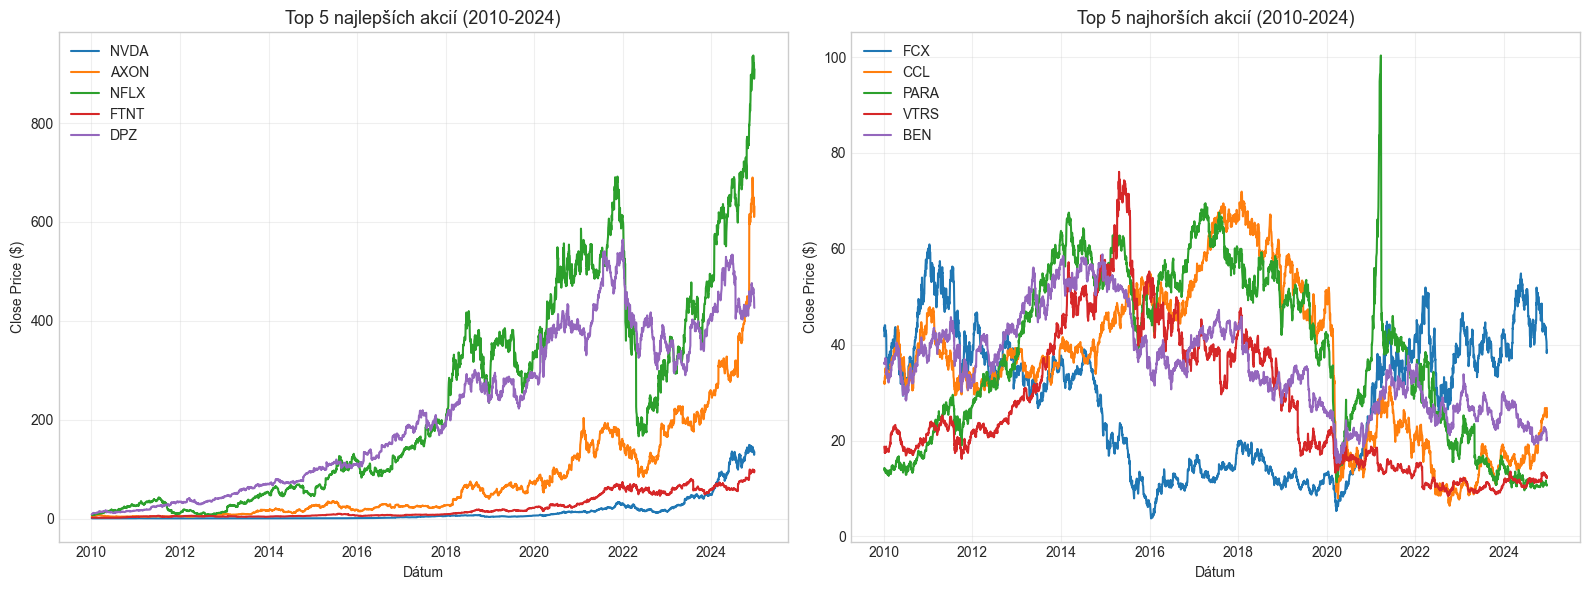

In [63]:
# C.1 Cenový vývoj - Top 5 best vs Top 5 worst
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 5 najlepších
for symbol in top5_best:
    stock_data = df_clean[df_clean['Symbol'] == symbol].sort_values('Date')
    axes[0].plot(stock_data['Date'], stock_data['Close'], label=symbol, linewidth=1.5)

axes[0].set_title('Top 5 najlepších akcií (2010-2024)', fontsize=13)
axes[0].set_xlabel('Dátum')
axes[0].set_ylabel('Close Price ($)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Top 5 najhorších
for symbol in top5_worst:
    stock_data = df_clean[df_clean['Symbol'] == symbol].sort_values('Date')
    axes[1].plot(stock_data['Date'], stock_data['Close'], label=symbol, linewidth=1.5)

axes[1].set_title('Top 5 najhorších akcií (2010-2024)', fontsize=13)
axes[1].set_xlabel('Dátum')
axes[1].set_ylabel('Close Price ($)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

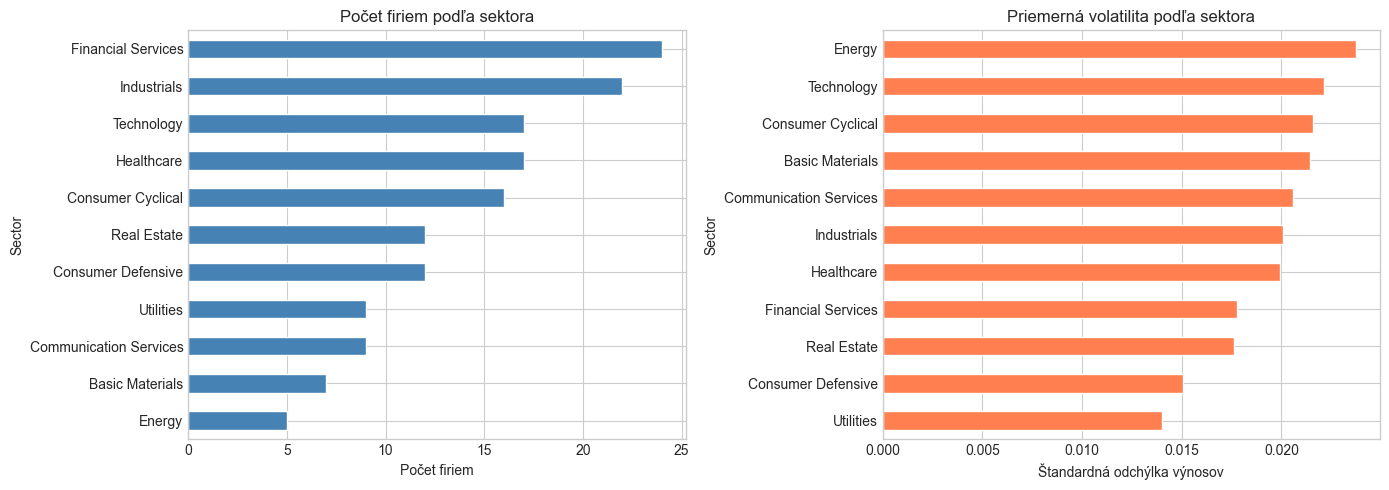

In [53]:
# C.4 Analýza sektorov
# Spojenie s df_companies
df_with_sector = df_clean.merge(df_companies[['Symbol', 'Sector', 'Industry']], on='Symbol', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Počet firiem podľa sektora
sector_counts = df_with_sector.groupby('Sector')['Symbol'].nunique().sort_values(ascending=True)
sector_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Počet firiem podľa sektora')
axes[0].set_xlabel('Počet firiem')

# Priemerná volatilita podľa sektora
sector_volatility = df_with_sector.groupby('Sector')['Daily_Return'].std().sort_values(ascending=True)
sector_volatility.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Priemerná volatilita podľa sektora')
axes[1].set_xlabel('Štandardná odchýlka výnosov')

plt.tight_layout()
plt.show()

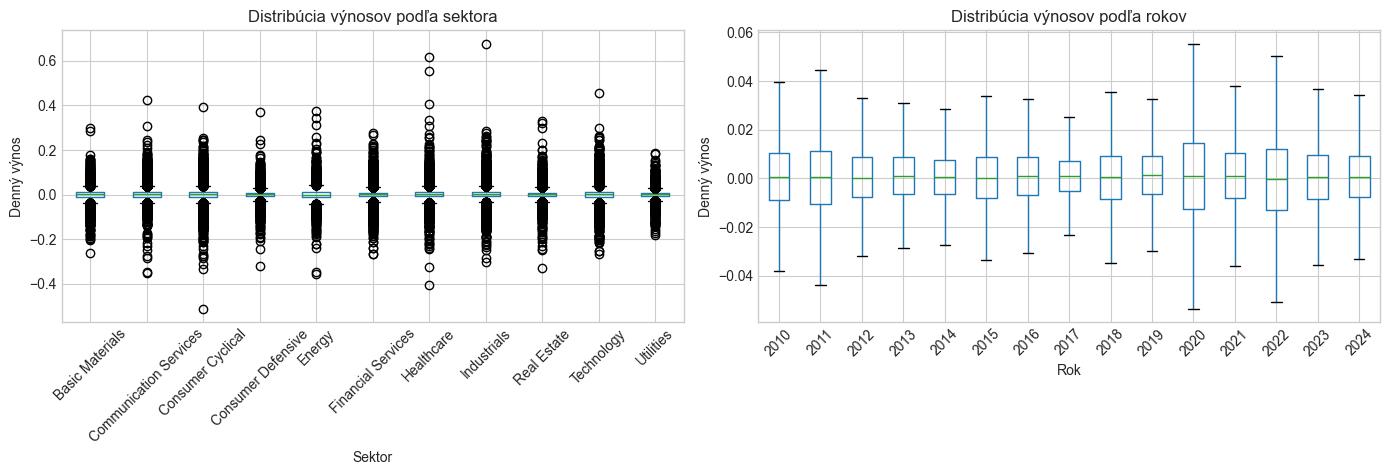

In [54]:
# C.5 Box plot a detekcia outlierov
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot výnosov podľa sektora
df_with_sector.boxplot(column='Daily_Return', by='Sector', ax=axes[0], 
                        vert=True, showfliers=True)
axes[0].set_title('Distribúcia výnosov podľa sektora')
axes[0].set_xlabel('Sektor')
axes[0].set_ylabel('Denný výnos')
axes[0].tick_params(axis='x', rotation=45)
plt.suptitle('')  # Odstránenie automatického titulku

# Časový box plot - výnosy podľa rokov
df_clean['Year'] = df_clean['Date'].dt.year
yearly_boxplot = df_clean.boxplot(column='Daily_Return', by='Year', ax=axes[1],
                                   vert=True, showfliers=False)
axes[1].set_title('Distribúcia výnosov podľa rokov')
axes[1].set_xlabel('Rok')
axes[1].set_ylabel('Denný výnos')
axes[1].tick_params(axis='x', rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

In [56]:
# C.5b - Extrémne výnosy (COVID crash, iné krízy)
print("="*60)
print("EXTRÉMNE VÝNOSY (OUTLIERS)")
print("="*60)

# Najväčšie jednodňové prepady
print("\nTop 10 najväčších jednodňových prepadov:")
worst_days = df_clean.nsmallest(10, 'Daily_Return')[['Date', 'Symbol', 'Close', 'Daily_Return']]
worst_days['Daily_Return_%'] = (worst_days['Daily_Return'] * 100).round(2)
print(worst_days.to_string(index=False))

# Najväčšie jednodňové nárasty
print("\nTop 10 najväčších jednodňových nárastov:")
best_days = df_clean.nlargest(10, 'Daily_Return')[['Date', 'Symbol', 'Close', 'Daily_Return']]
best_days['Daily_Return_%'] = (best_days['Daily_Return'] * 100).round(2)
print(best_days.to_string(index=False))

EXTRÉMNE VÝNOSY (OUTLIERS)

Top 10 najväčších jednodňových prepadov:
      Date Symbol      Close  Daily_Return  Daily_Return_%
2011-12-21   EXPE  27.889999     -0.511559          -51.16
2024-07-26   DXCM  64.000000     -0.406583          -40.66
2017-07-05    BKR  37.250000     -0.354196          -35.42
2022-04-20   NFLX 226.190002     -0.351166          -35.12
2011-10-25   NFLX  11.052857     -0.348957          -34.90
2016-02-08    WMB  11.160000     -0.348131          -34.81
2020-04-01    CCL   8.800000     -0.331815          -33.18
2010-10-06   EQIX  70.339996     -0.330669          -33.07
2017-09-28   DXCM  11.360000     -0.326516          -32.65
2024-08-29     DG  84.029999     -0.321463          -32.15

Top 10 najväčších jednodňových nárastov:
      Date Symbol     Close  Daily_Return  Daily_Return_%
2015-04-13   BLDR 11.570000      0.676812           67.68
2013-04-19   VRTX 85.599998      0.619066           61.91
2012-05-07   VRTX 58.119999      0.553595           55.36
2013-04-

## 4.1b Zdôvodnenie výberu ML/DL metód vzhľadom na vybraný dataset pre 4.2

# 4.2 Modeling and evaluation
